In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load taxis dataset
df = sns.load_dataset("taxis")

# Display first few rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
# Check missing values
df.isnull().sum()

# Impute numerical columns with median
num_cols = df.select_dtypes(include=['float64','int64']).columns
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)   # assign back safely

# Impute categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)     # assign back safely

# Drop rows if critical columns still have missing values
df = df.dropna(subset=['pickup','dropoff','fare'])

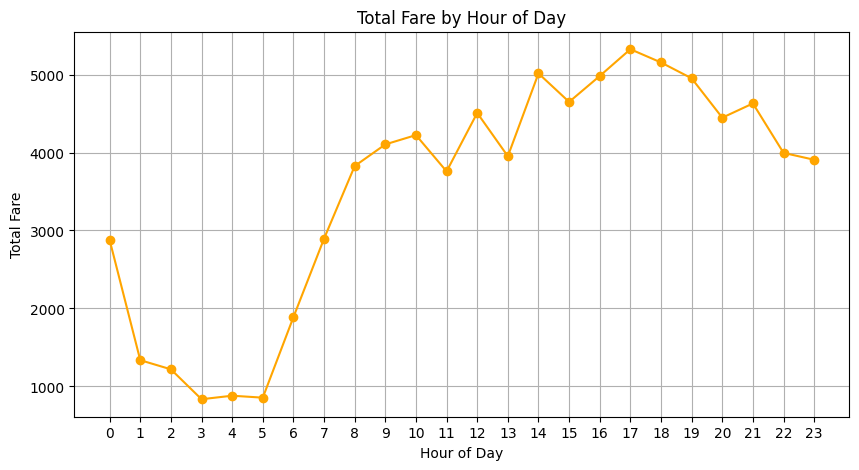

In [3]:
#Line chart - Convert pickup to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Group by hour of day
hourly_fares = df.groupby(df['pickup'].dt.hour)['fare'].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(hourly_fares.index, hourly_fares.values, marker='o', color='orange')
plt.title("Total Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Fare")
plt.xticks(range(0,24))   # show all 24 hours
plt.grid(True)
plt.show()

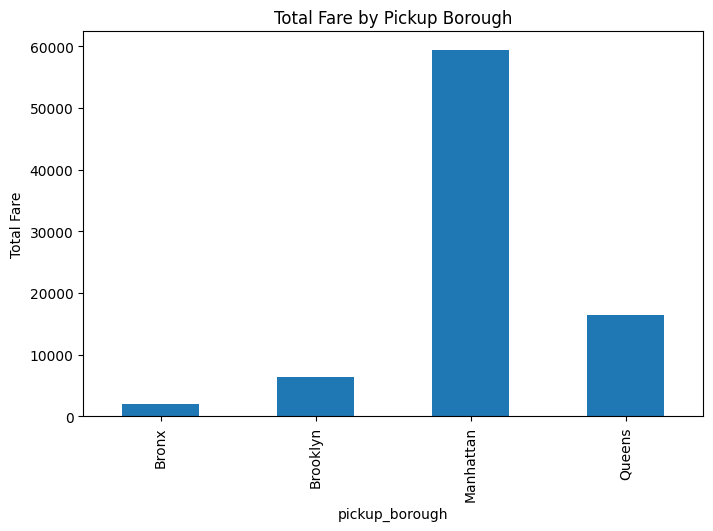

In [4]:
# Bar Chart – Total Fare per Borough
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()
fare_by_borough.plot(kind='bar', figsize=(8,5))
plt.title("Total Fare by Pickup Borough")
plt.ylabel("Total Fare")
plt.show()

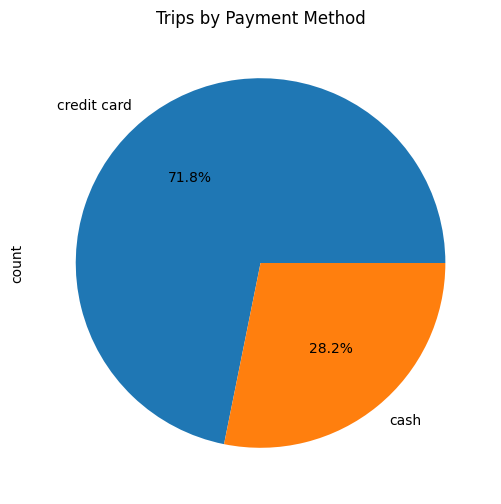

In [5]:
# Pie Chart – Payment Method Distribution
payment_counts = df['payment'].value_counts()
payment_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Trips by Payment Method")
plt.show()

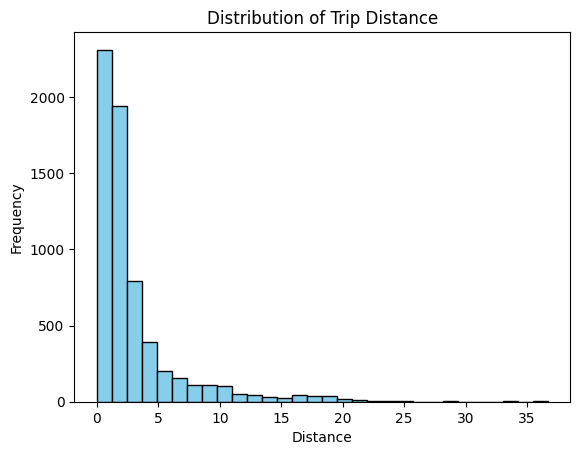

In [6]:
# Histogram – Distance Distribution
plt.hist(df['distance'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

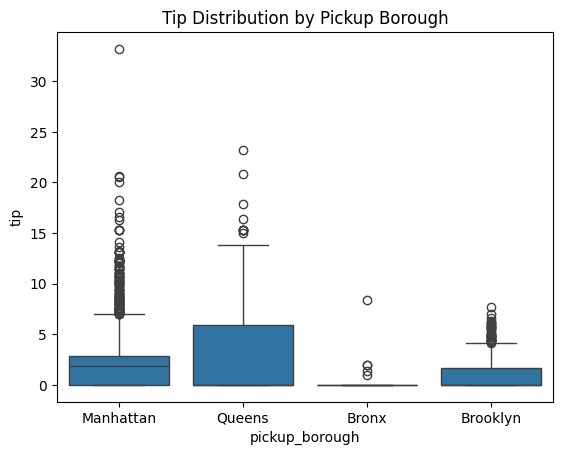

In [7]:
#Box Plot – Tip by Borough
sns.boxplot(x='pickup_borough', y='tip', data=df)
plt.title("Tip Distribution by Pickup Borough")
plt.show()

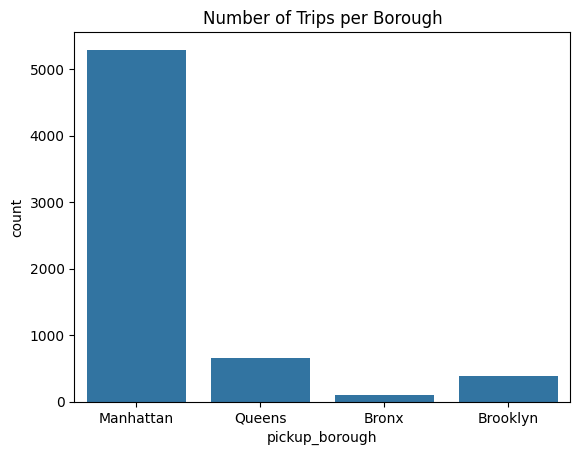

In [8]:
# Count Plot – Trips per Borough
sns.countplot(x='pickup_borough', data=df)
plt.title("Number of Trips per Borough")
plt.show()

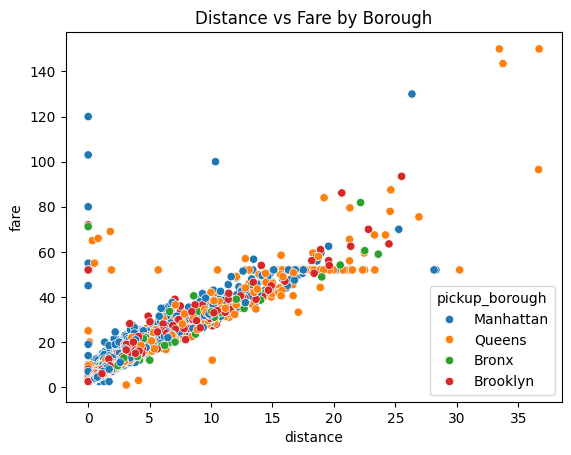

In [9]:
# Scatter Plot – Distance vs Fare
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df)
plt.title("Distance vs Fare by Borough")
plt.show()

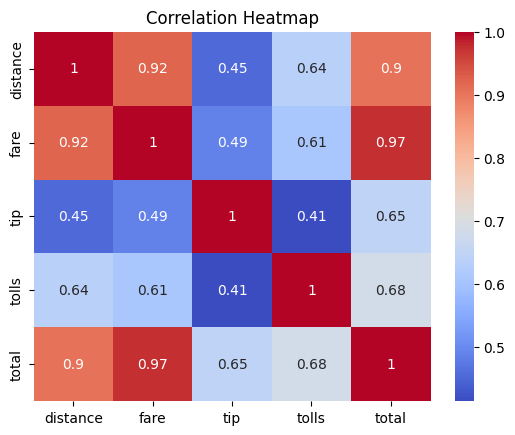

In [10]:
# Heatmap – Correlation Matrix
corr = df[['distance','fare','tip','tolls','total']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

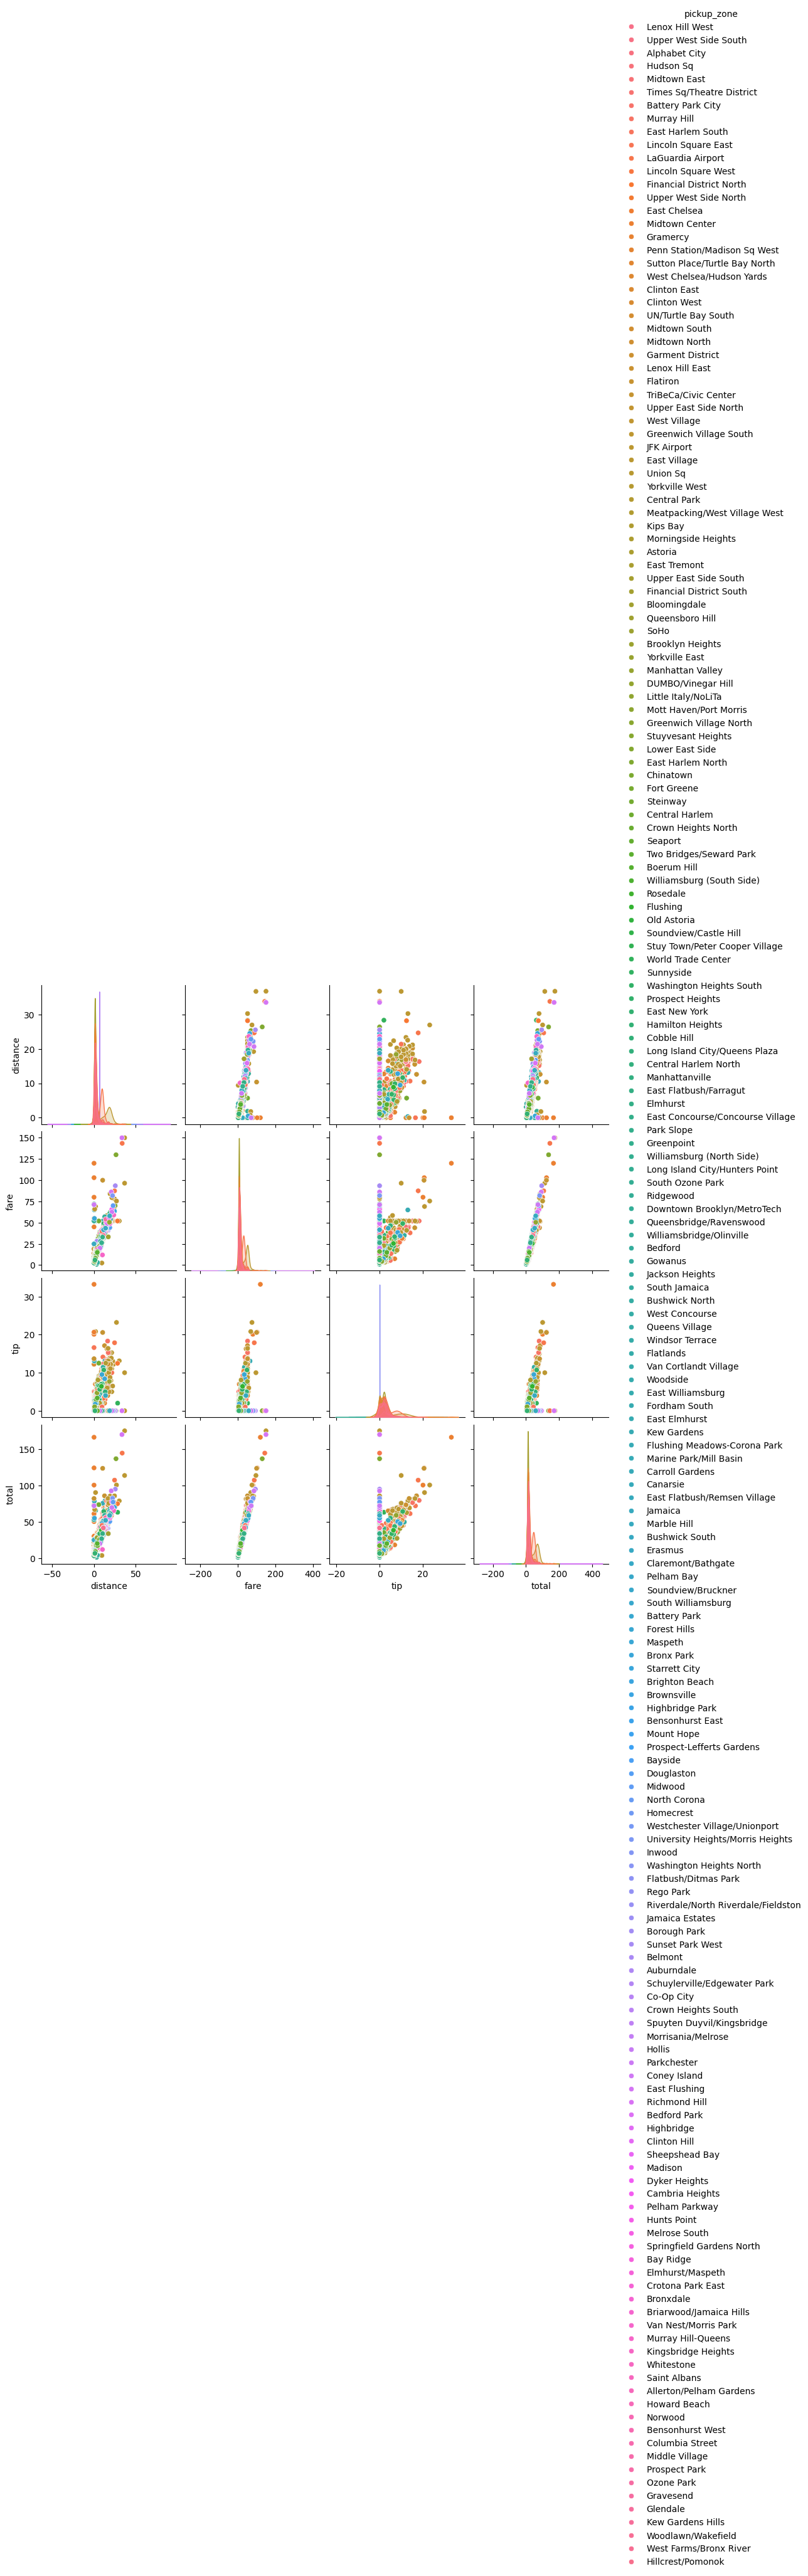

In [11]:
# Pair Plot – Distance, Fare, Tip, Total
sns.pairplot(df[['distance','fare','tip','total','pickup_zone']], hue='pickup_zone')
plt.show()


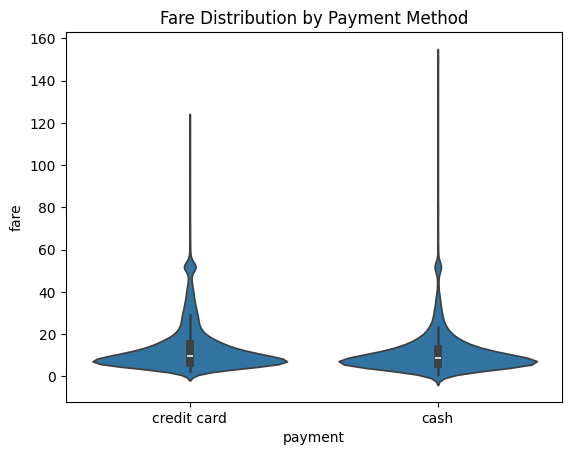

In [12]:
# Violin Plot – Fare by Payment Method
sns.violinplot(x='payment', y='fare', data=df)
plt.title("Fare Distribution by Payment Method")
plt.show()